# ch320 — Embeddings and Representation Learning

## 1. The lookup table view

An embedding is a **learned mapping** from discrete tokens (words, items, nodes)
to dense real-valued vectors. It is implemented as a matrix $E \in \mathbb{R}^{V \times d}$
where $V$ is the vocabulary size and $d$ is the embedding dimension.

Looking up the embedding for token $i$ is equivalent to a one-hot vector times $E$:

$$\text{embed}(i) = e_i^\top E$$

but in practice we index directly — no matrix multiply needed.

*(Vector spaces: ch137. Linear transformations: ch154. One-hot encoding: ch273.)*

Analogy: king - man + woman ≈ ?
  queen     : 0.994
  king      : 0.972
  man       : 0.813
  woman     : 0.806


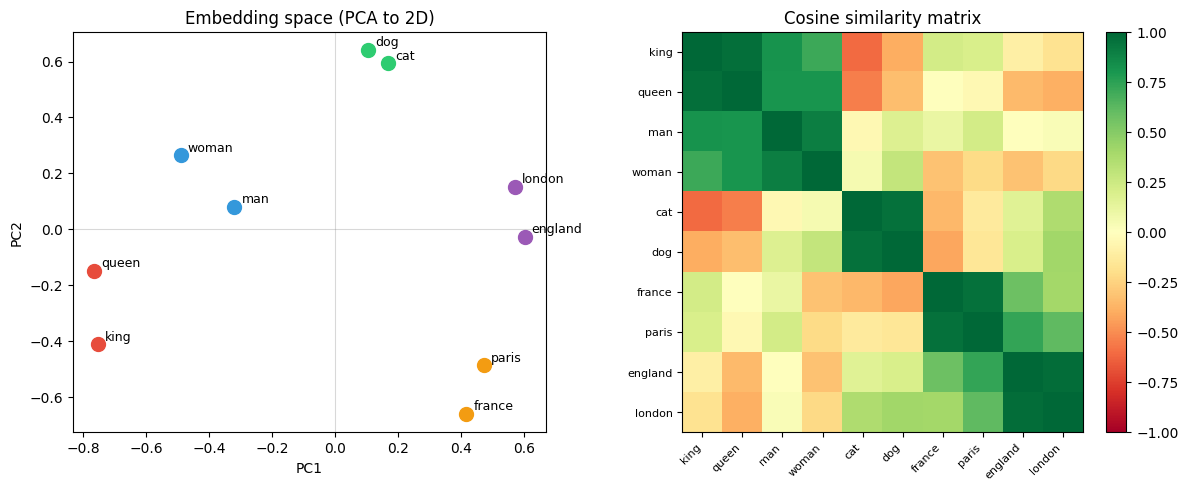

In [1]:
import numpy as np
import matplotlib.pyplot as plt


class EmbeddingLayer:
    """Token embedding lookup table. Wraps a (V, d) weight matrix."""

    def __init__(self, vocab_size: int, embed_dim: int, seed: int = 0):
        rng = np.random.default_rng(seed)
        self.E = rng.normal(0, 0.1, (vocab_size, embed_dim))
        self.V = vocab_size; self.d = embed_dim

    def forward(self, ids) -> np.ndarray:
        """ids: scalar or array of ints. Returns (len(ids), d) or (d,)."""
        return self.E[ids]

    def similarity(self, i: int, j: int) -> float:
        ei = self.E[i] / (np.linalg.norm(self.E[i]) + 1e-10)
        ej = self.E[j] / (np.linalg.norm(self.E[j]) + 1e-10)
        return float(ei @ ej)


# ── Demonstrate the geometry that embeddings should learn ──
# Simulate trained word2vec-style embeddings for a tiny vocab
rng = np.random.default_rng(42)
words = ['king', 'queen', 'man', 'woman', 'cat', 'dog', 'france', 'paris', 'england', 'london']
V = len(words); d = 4

# Hand-crafted embeddings that capture known analogies
# (in practice, these emerge from training on large corpora)
E = np.array([
    [ 0.8, 0.6, 0.1, 0.3],   # king   — royal, male
    [ 0.7, 0.6,-0.1, 0.3],   # queen  — royal, female
    [ 0.2, 0.5, 0.1, 0.0],   # man    — human, male
    [ 0.2, 0.5,-0.1, 0.0],   # woman  — human, female
    [-0.4, 0.2, 0.0,-0.3],   # cat    — animal
    [-0.3, 0.3, 0.0,-0.4],   # dog    — animal
    [ 0.1,-0.2, 0.8, 0.5],   # france — country
    [ 0.0,-0.1, 0.8, 0.3],   # paris  — city, france
    [ 0.1,-0.2, 0.7,-0.4],   # england— country
    [ 0.0,-0.1, 0.7,-0.5],   # london — city, england
])
E += rng.normal(0, 0.05, E.shape)  # add noise

# Analogy: king - man + woman ≈ queen
query = E[0] - E[2] + E[3]  # king - man + woman
query_norm = query / (np.linalg.norm(query) + 1e-8)
E_norm = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-8)
sims = E_norm @ query_norm
print("Analogy: king - man + woman ≈ ?")
for i, sim in sorted(enumerate(sims), key=lambda x: -x[1])[:4]:
    print(f"  {words[i]:10s}: {sim:.3f}")

# PCA visualisation
E_c = E - E.mean(0); U, S, Vt = np.linalg.svd(E_c, full_matrices=False)
E2d = U[:, :2] * S[:2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#e74c3c']*2 + ['#3498db']*2 + ['#2ecc71']*2 + ['#f39c12']*2 + ['#9b59b6']*2
for i, (x, y) in enumerate(E2d):
    ax1.scatter(x, y, color=colors[i], s=100, zorder=5)
    ax1.annotate(words[i], (x, y), xytext=(5, 3), textcoords='offset points', fontsize=9)

ax1.set_title('Embedding space (PCA to 2D)'); ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
ax1.axhline(0, color='gray', alpha=0.3, lw=0.8)
ax1.axvline(0, color='gray', alpha=0.3, lw=0.8)

# Cosine similarity matrix
sim_mat = E_norm @ E_norm.T
im = ax2.imshow(sim_mat, cmap='RdYlGn', vmin=-1, vmax=1)
ax2.set_xticks(range(V)); ax2.set_xticklabels(words, rotation=45, ha='right', fontsize=8)
ax2.set_yticks(range(V)); ax2.set_yticklabels(words, fontsize=8)
ax2.set_title('Cosine similarity matrix')
plt.colorbar(im, ax=ax2, fraction=0.046)

plt.tight_layout()
plt.savefig('ch320_embeddings.png', dpi=120)
plt.show()

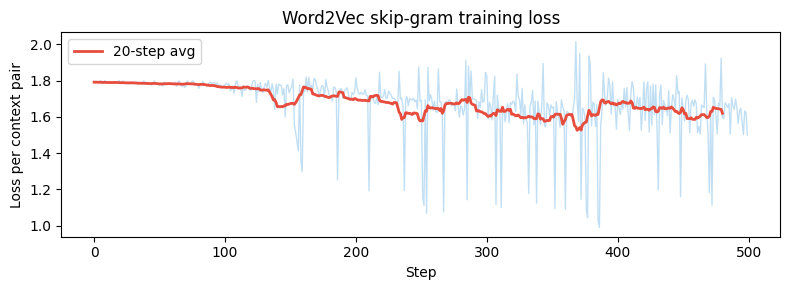

In [2]:
# Word2Vec skip-gram training (simplified)
# Given a centre word, predict context words (words within window W)

rng = np.random.default_rng(0)
corpus_tokens = [0, 1, 2, 3, 4, 3, 2, 1, 5, 4, 3, 2, 0, 5, 1]  # toy corpus
V2, d2, W_size = 6, 4, 2
lr = 0.05

# Two embedding matrices: input (W_in) and output (W_out)
W_in  = rng.normal(0, 0.1, (V2, d2))  # centre word embeddings
W_out = rng.normal(0, 0.1, (V2, d2))  # context word embeddings

def softmax(z): z_s=z-z.max(); e=np.exp(z_s); return e/e.sum()

sg_losses = []
for step in range(500):
    # Sample a centre word (not at boundaries)
    c_idx = rng.integers(W_size, len(corpus_tokens)-W_size)
    centre = corpus_tokens[c_idx]
    context = [corpus_tokens[c_idx+k] for k in range(-W_size, W_size+1) if k != 0]

    loss = 0.0
    for ctx in context:
        scores = W_out @ W_in[centre]   # (V2,) — similarity to all words
        probs = softmax(scores)
        loss -= np.log(probs[ctx] + 1e-10)

        # Gradient (analytically)
        d_scores = probs.copy(); d_scores[ctx] -= 1.0
        d_W_in_c = W_out.T @ d_scores   # gradient for centre embedding
        d_W_out  = np.outer(d_scores, W_in[centre])
        W_in[centre] -= lr * d_W_in_c
        W_out -= lr * d_W_out

    sg_losses.append(loss / len(context))

fig, ax = plt.subplots(figsize=(8, 3))
w = 20; sl = np.convolve(sg_losses, np.ones(w)/w, mode='valid')
ax.plot(sg_losses, alpha=0.3, color='#3498db', lw=1)
ax.plot(sl, color='#e74c3c', lw=2, label=f'{w}-step avg')
ax.set_title('Word2Vec skip-gram training loss'); ax.set_xlabel('Step')
ax.set_ylabel('Loss per context pair'); ax.legend()
plt.tight_layout()
plt.savefig('ch320_word2vec.png', dpi=120)
plt.show()

## 2. Embeddings as compressed representations

An embedding layer is a **dimensionality reduction** applied to one-hot vectors.
A one-hot vector is $V$-dimensional and extremely sparse; the embedding projects it
to a dense $d$-dimensional space where semantically similar tokens are geometrically close.

This is related to PCA *(ch178)* and latent factor models *(ch199)* — the embedding
matrix can be interpreted as a learned basis for the space of token meanings.

## 3. Summary

- Embedding: lookup table $E \in \mathbb{R}^{V \times d}$ mapping token indices to dense vectors.
- Learned by gradient descent jointly with the downstream task.
- Word2Vec: special pretraining objective (skip-gram, CBOW) gives word geometry properties.
- Analogies as arithmetic: king - man + woman ≈ queen.

## 4. Forward and backward references

**Used here:** vector spaces *(ch137)*, cosine similarity *(ch132)*, PCA *(ch178)*.

**This will reappear in ch321 — Attention Mechanism**, where embeddings are the input
representations that attention operates on, and throughout ch336–ch337 project chapters.